# A01 Full Results

This notebook rebuilds the appendix full-cutoff results view and provides a compact heatmap of RouteRec deltas against the strongest baseline.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

CSV_PATH = RESULTS_ROOT / "A01_full_results/A01_full_results.csv"
REQUIRED_COLUMNS = [
    "paper_section", "panel", "dataset", "variant_or_model", "metric", "cutoff", "value",
    "split", "selection_rule", "run_id", "source_path", "notes",
]


def demo_full_results() -> pd.DataFrame:
    rows = []
    demo_values = {
        ("Beauty", "RouteRec"): [0.0988, 0.1256, 0.1589, 0.0745, 0.0826, 0.0896, 0.0687, 0.0739, 0.0763],
        ("Beauty", "FEARec"): [0.0952, 0.1219, 0.1548, 0.0717, 0.0798, 0.0871, 0.0661, 0.0713, 0.0741],
        ("Foursquare", "RouteRec"): [0.2049, 0.2447, 0.2939, 0.1457, 0.1589, 0.1718, 0.1339, 0.1400, 0.1430],
        ("Foursquare", "SASRec"): [0.1964, 0.2361, 0.2850, 0.1396, 0.1527, 0.1655, 0.1282, 0.1344, 0.1378],
        ("KuaiRec", "RouteRec"): [0.1451, 0.1832, 0.2287, 0.1138, 0.1264, 0.1376, 0.1079, 0.1147, 0.1185],
        ("KuaiRec", "DuoRec"): [0.1434, 0.1809, 0.2261, 0.1116, 0.1241, 0.1352, 0.1056, 0.1123, 0.1164],
    }
    metric_specs = [("HR", 5), ("HR", 10), ("HR", 20), ("NDCG", 5), ("NDCG", 10), ("NDCG", 20), ("MRR", 5), ("MRR", 10), ("MRR", 20)]
    for (dataset, model), values in demo_values.items():
        for (metric, cutoff), value in zip(metric_specs, values):
            rows.append(
                {
                    "paper_section": "A01_full_results",
                    "panel": "full_results",
                    "dataset": dataset,
                    "variant_or_model": model,
                    "metric": metric,
                    "cutoff": cutoff,
                    "value": value,
                    "split": "test",
                    "selection_rule": "demo",
                    "run_id": "demo",
                    "source_path": "demo",
                    "notes": "demo data",
                }
            )
    return pd.DataFrame(rows)


In [2]:
df, mode = load_csv_or_demo(CSV_PATH, REQUIRED_COLUMNS, demo_builder=demo_full_results)
display(Markdown(f"**Load mode:** {mode}"))
display(df.head())


**Load mode:** demo

,paper_section,panel,dataset,variant_or_model,metric,cutoff,value,split,selection_rule,run_id,source_path,notes
0,A01_full_results,full_results,Beauty,RouteRec,HR,5,0.0988,test,demo,demo,demo,demo data
1,A01_full_results,full_results,Beauty,RouteRec,HR,10,0.1256,test,demo,demo,demo,demo data
2,A01_full_results,full_results,Beauty,RouteRec,HR,20,0.1589,test,demo,demo,demo,demo data
3,A01_full_results,full_results,Beauty,RouteRec,NDCG,5,0.0745,test,demo,demo,demo,demo data
4,A01_full_results,full_results,Beauty,RouteRec,NDCG,10,0.0826,test,demo,demo,demo,demo data


metric_at_k                   HR@10   HR@20    HR@5  MRR@10  MRR@20   MRR@5  \
dataset    variant_or_model                                                   
Beauty     FEARec            0.1219  0.1548  0.0952  0.0713  0.0741  0.0661   
           RouteRec          0.1256  0.1589  0.0988  0.0739  0.0763  0.0687   
Foursquare RouteRec          0.2447  0.2939  0.2049  0.1400  0.1430  0.1339   
           SASRec            0.2361  0.2850  0.1964  0.1344  0.1378  0.1282   
KuaiRec    DuoRec            0.1809  0.2261  0.1434  0.1123  0.1164  0.1056   
           RouteRec          0.1832  0.2287  0.1451  0.1147  0.1185  0.1079   

metric_at_k                  NDCG@10  NDCG@20  NDCG@5  
dataset    variant_or_model                            
Beauty     FEARec             0.0798   0.0871  0.0717  
           RouteRec           0.0826   0.0896  0.0745  
Foursquare RouteRec           0.1589   0.1718  0.1457  
           SASRec             0.1527   0.1655  0.1396  
KuaiRec    DuoRec             0.1241   0.1352  0.1116  
           RouteRec           0.1264   0.1376  0.1138

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/A01_full_results_delta_heatmap.png, /workspace/FeaturedMoE/writing/results/generated_figures/A01_full_results_delta_heatmap.pdf

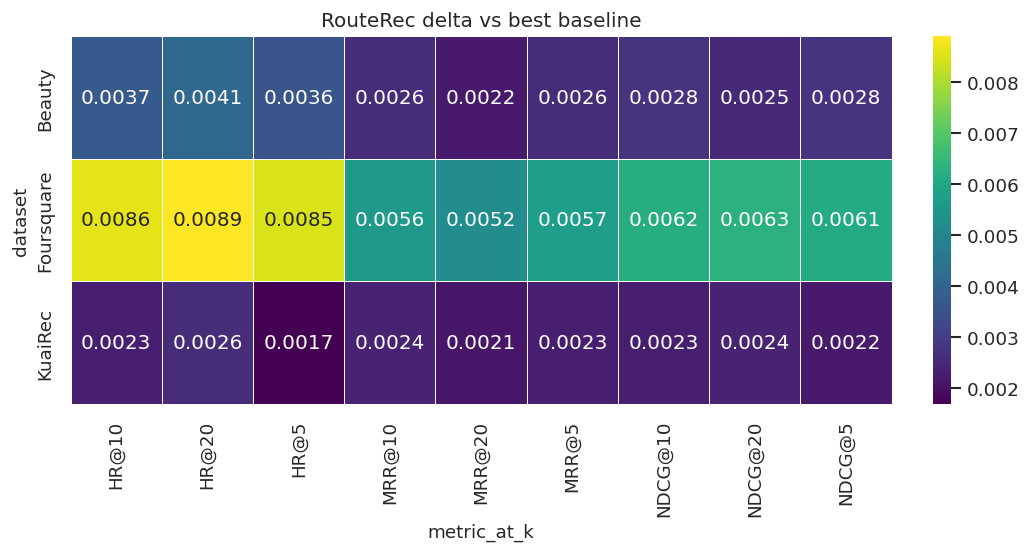

In [3]:
preview = df.copy()
preview["metric_at_k"] = preview["metric"] + "@" + preview["cutoff"].astype(str)
display(preview.pivot_table(index=["dataset", "variant_or_model"], columns="metric_at_k", values="value"))

metric_heatmap = preview.copy()
route_df = metric_heatmap[metric_heatmap["variant_or_model"] == "RouteRec"].copy()
baseline_df = metric_heatmap[metric_heatmap["variant_or_model"] != "RouteRec"].groupby(["dataset", "metric_at_k"], as_index=False)["value"].max().rename(columns={"value": "best_baseline"})
delta_df = route_df.merge(baseline_df, on=["dataset", "metric_at_k"], how="inner")
delta_df["delta"] = delta_df["value"] - delta_df["best_baseline"]

fig, ax = plt.subplots(figsize=(8.5, 4.5), constrained_layout=True)
heatmap_from_long(delta_df, index="dataset", columns="metric_at_k", values="delta", ax=ax, title="RouteRec delta vs best baseline", cmap="viridis", fmt=".4f")
saved_paths = export_figure(fig, "A01_full_results_delta_heatmap", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
